In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay # Рисуем опорные векторы и зазор
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 0. Создаем учебный датасет

In [3]:
X_train = np.array([
    [29, 64],
    [28, 49],
    [32, 59],
    [28, 67],
    [41, 54],
    [41, 67],
    [35, 66],
    [42, 84],
    [55, 80],
    [30, 35],
    [25, 15],
    [50, 60],
    [40, 85]
])

y_train = [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0]

data = pd.DataFrame(X_train)
data.columns = ['Age', 'Income']
data['Default'] = y_train

In [8]:
data

,Age,Income,Default
0,29,64,1
1,28,49,1
2,32,59,1
3,28,67,1
4,41,54,0
5,41,67,0
6,35,66,0
7,42,84,0
8,55,80,0
9,30,35,1


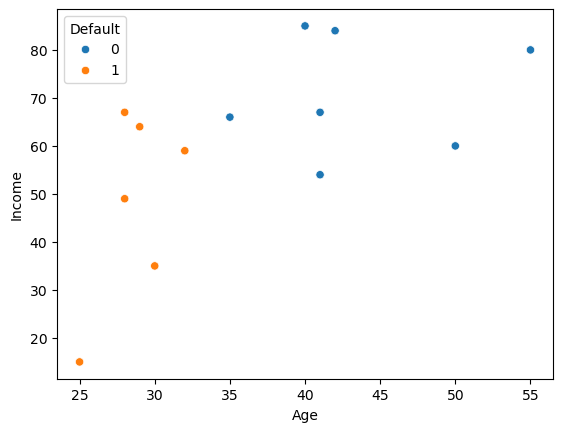

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default')
plt.show()

In [6]:
def draw_svm(data, X_train, clf):
  fig, ax = plt.subplots()
  sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default')
  ax = plt.gca()

  DecisionBoundaryDisplay.from_estimator(
      clf,
      X_train,
      plot_method="contour",
      colors="k",
      levels=[-1, 0, 1],
      alpha=0.5,
      linestyles=["--", "-", "--"],
      ax=ax,
  )

  ax.scatter(
      clf.support_vectors_[:, 0],
      clf.support_vectors_[:, 1],
      s=100,
      linewidth=1,
      facecolors="none",
      edgecolors="k",
  )

  plt.show()

# 1. SVM с жестким зазором

In [5]:
model = SVC(kernel = 'linear') # kernel - функция ядра, форма разделяющей линии
model.fit(X_train, y_train)

SVC(kernel='linear')

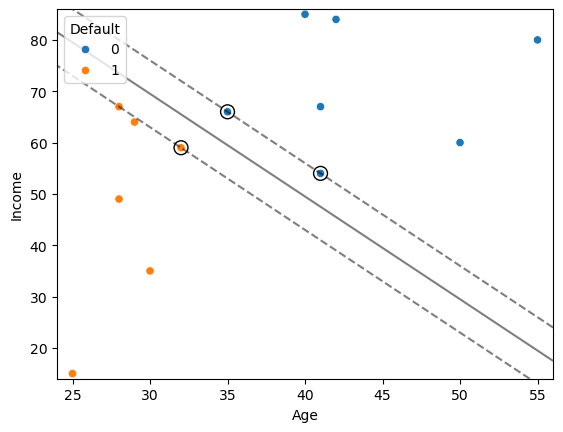

In [7]:
draw_svm(data, X_train, model)

Как узнать уравнение прямой?

In [11]:
print("Коэффициенты:", model.coef_)
print("Свободный член:", model.intercept_)

Коэффициенты: [[-0.30776281 -0.15381594]]
Свободный член: [19.92381221]


Уравнение разделяющей прямой:

$-0.30776 \cdot Age - 0.15382 \cdot Income + 19.9238 = 0$

In [27]:
# Классифицируем заемщика возраста 40 лет и с доходом 50 тыс рублей
# Подставим в уравнение разделяющей прямой Age = 40 и Income = 50
model.coef_[0,0]*40 + model.coef_[0,1]*50 + model.intercept_

array([-0.07749721])

Такое наблюдение находится внутри зазора и выше прямой, должно классифицироваться как добросовестный заемщик

In [28]:
model.predict(np.array([40, 50]).reshape(1, -1))

array([0])

# 2. SVM с мягким зазором

In [29]:
X_train = np.array([
    [29, 64],
    [28, 49],
    [32, 59],
    [48, 67],
    [31, 54],
    [41, 67],
    [35, 66],
    [42, 84],
    [55, 80],
    [30, 35],
    [25, 15],
    [50, 60],
    [40, 85]
])

y_train = [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0]

data = pd.DataFrame(X_train)
data.columns = ['Age', 'Income']
data['Default'] = y_train

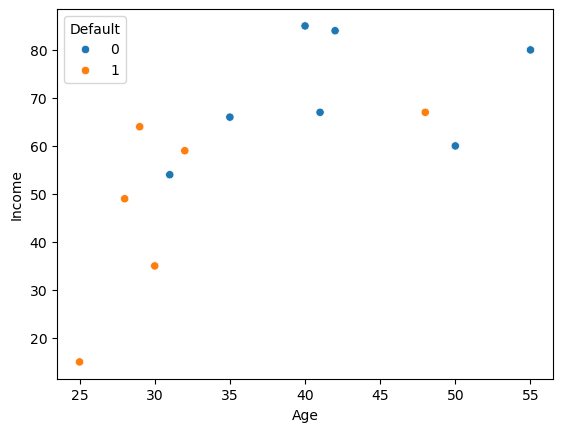

In [30]:
fig, ax = plt.subplots()
sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default')
plt.show()

In [59]:
model = SVC(kernel = 'linear') # kernel - функция ядра, форма разделяющей линии
model.fit(X_train, y_train)

SVC(kernel='linear')

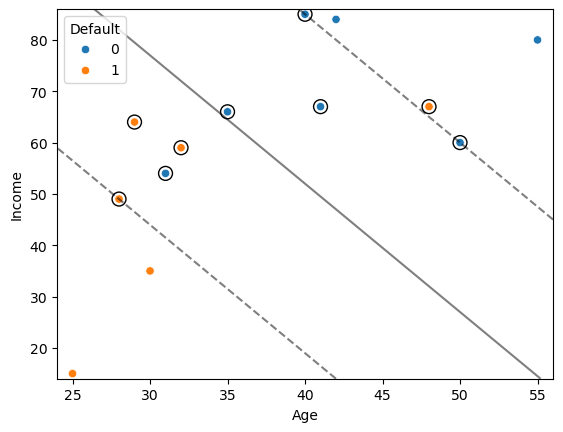

In [60]:
draw_svm(data, X_train, model)

In [33]:
# Координаты опорных векторов
support_vectors = model.support_vectors_
support_vectors

array([[31., 54.],
       [41., 67.],
       [35., 66.],
       [50., 60.],
       [40., 85.],
       [29., 64.],
       [28., 49.],
       [32., 59.],
       [48., 67.]])

In [34]:
print("Коэффициенты:", model.coef_)
print("Свободный член:", model.intercept_)

Коэффициенты: [[-0.07573596 -0.03029439]]
Свободный член: [4.60465158]


$$ - 0.0757 \cdot Age_i - 0.0303 \cdot Income_i + 4.6047 = 0 $$

$$ Income_i  = \frac{-4.6047 + 0.0757 \cdot Age_i} {- 0.0303} $$

$$ Income_i  = 152 - 2.5 \cdot Age_i $$

# 3. Функции ядра в SVM

Линейная:

$ \phi(x) = x_i x'$

Полиномиальная:

$ \phi(x) =  (\gamma \cdot x_i x' + r)^d$

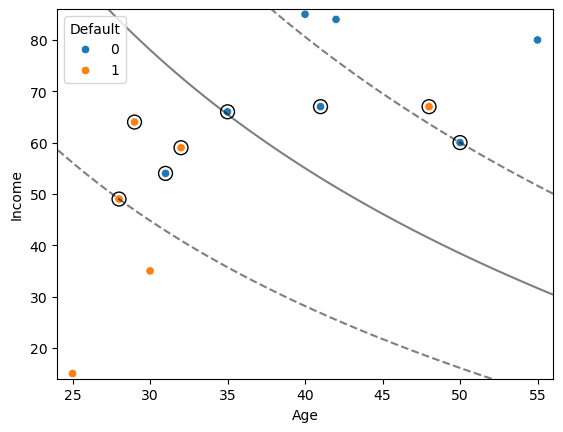

In [36]:
model = SVC(kernel = 'poly', degree = 2).fit(X_train, y_train)
draw_svm(data, X_train, model)

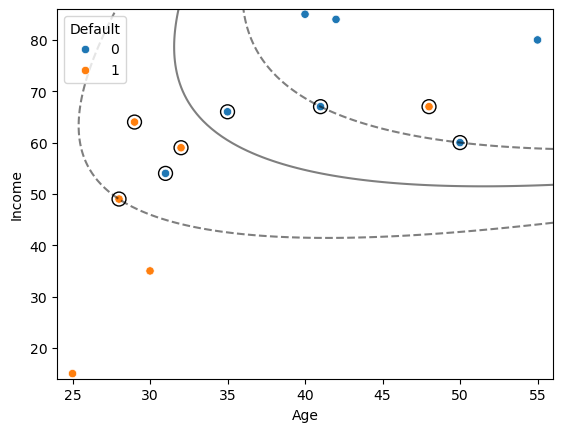

In [61]:
model = SVC(kernel = 'poly', degree = 3).fit(X_train, y_train)
draw_svm(data, X_train, model)

Гауссова (radial-based):

$ \phi(x) =  e^{-\gamma ||x_i  x' ||} $

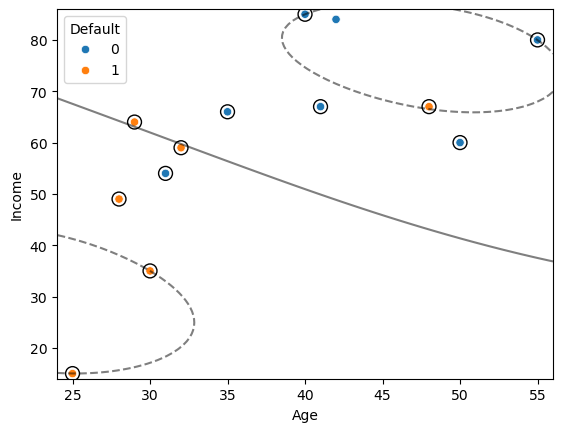

In [62]:
model = SVC(kernel = 'rbf').fit(X_train, y_train)
draw_svm(data, X_train, model)

# 4. Дерево решений

In [65]:
X_train = np.array([
    [29, 64],
    [28, 49],
    [32, 59],
    [48, 67],
    [31, 54],
    [41, 67],
    [35, 66],
    [42, 84],
    [55, 80],
    [30, 35],
    [25, 15],
    [50, 60],
    [40, 85]
])

y_train = [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0]

data = pd.DataFrame(X_train)
data.columns = ['Age', 'Income']
data['Default'] = y_train

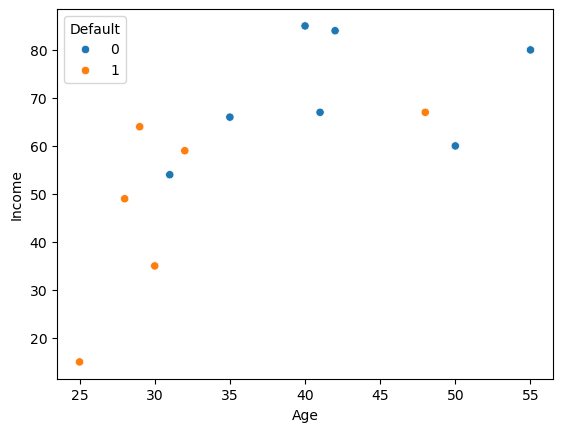

In [66]:
fig, ax = plt.subplots()
sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default')
plt.show()

In [67]:
model = DecisionTreeClassifier(random_state = 42)
model.fit(data[['Age', 'Income']], data['Default'])

DecisionTreeClassifier(random_state=42)

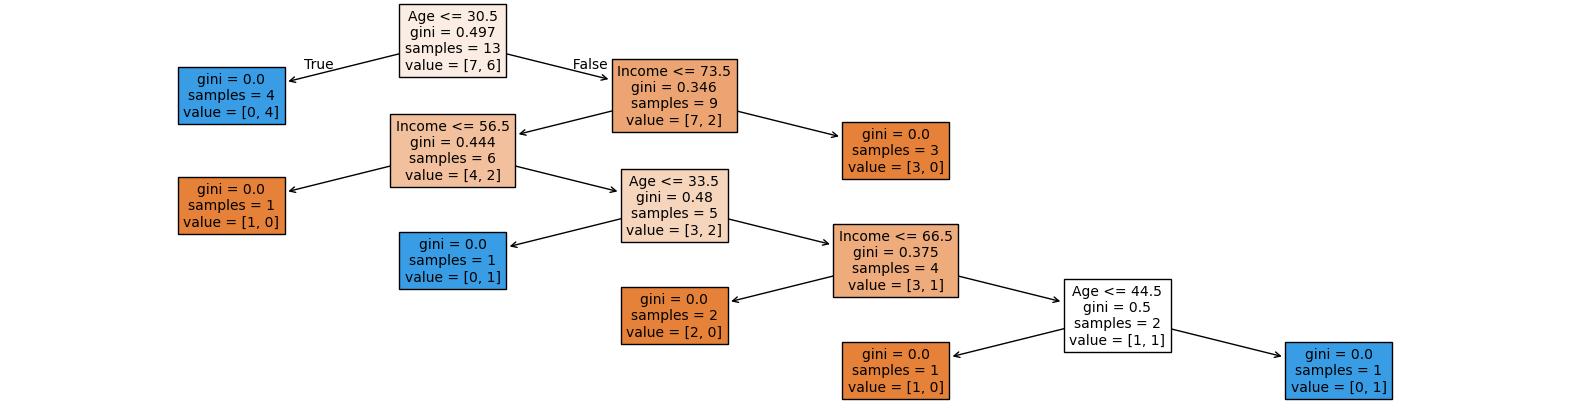

In [68]:
fig, ax = plt.subplots(figsize = (20,5))
ax = plot_tree(model, filled = True, feature_names =['Age', 'Income'], fontsize = 10)
plt.show()

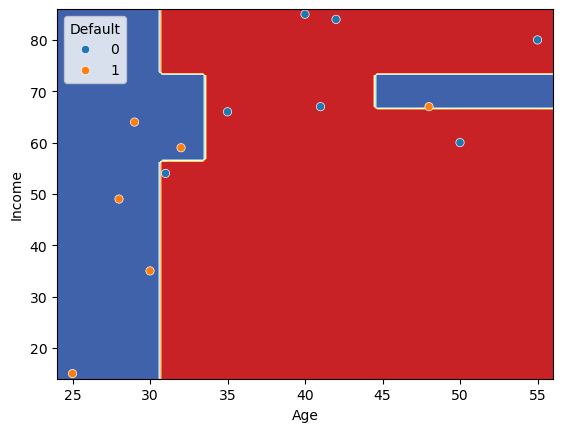

In [69]:
fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
      model,
      data[['Age', 'Income']],
      cmap=plt.cm.RdYlBu,
      response_method="predict_proba",
      ax=ax,
      xlabel = 'Age',
      ylabel = 'Income',
)

sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default', ax = ax)

plt.show()

# 5. Боремся с переобучением

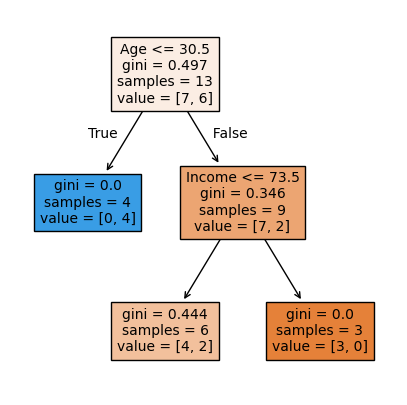

In [71]:
# Ограничиваем глубину дерева
model = DecisionTreeClassifier(max_depth = 2, random_state = 42)
model.fit(data[['Age', 'Income']], data['Default'])
fig, ax = plt.subplots(figsize = (5,5))
ax = plot_tree(model, filled = True, feature_names =['Age', 'Income'], fontsize = 10)
plt.show()

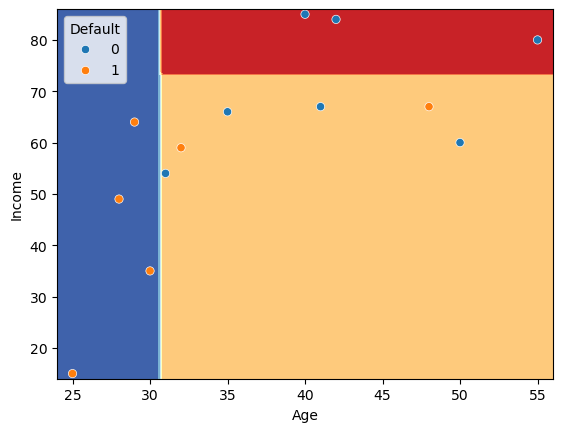

In [72]:
fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
      model,
      data[['Age', 'Income']],
      cmap=plt.cm.RdYlBu,
      response_method="predict_proba",
      ax=ax,
      xlabel = 'Age',
      ylabel = 'Income',
)

sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default', ax = ax)

plt.show()

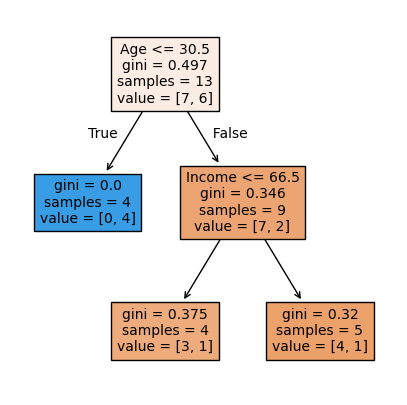

In [77]:
# Органичиваем минимальное количество наблюдений в одном терминальном узле
model = DecisionTreeClassifier(min_samples_leaf = 4, random_state = 42).fit(data[['Age', 'Income']], data['Default'])
fig, ax = plt.subplots(figsize = (5, 5))
ax = plot_tree(model, filled = True, feature_names = ['Age', 'Income'], fontsize = 10)
plt.show()

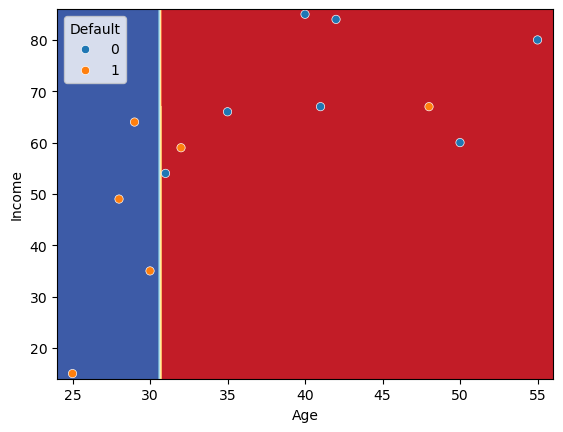

In [78]:
fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
      model,
      data[['Age', 'Income']],
      cmap=plt.cm.RdYlBu,
      response_method="predict_proba",
      ax=ax,
      xlabel = 'Age',
      ylabel = 'Income',
)

sns.scatterplot(data = data, x = 'Age', y = 'Income', hue = 'Default', ax = ax)

plt.show()